# Microglia Single-Cell RNA-seq Analysis
## Mathys et al., 2017 - Cell Reports

**Paper**: Temporal Tracking of Microglia Activation in Neurodegeneration at Single-Cell Resolution  
**Data**: GEO GSE103334  
**Goal**: Exploratory analysis of microglia cell states during neurodegeneration

In [35]:
import sys
from pathlib import Path

# Add parent directory to path
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully!")
out_dir = Path('../../outputs/GSE103334')
out_dir.mkdir(parents=True, exist_ok=True)


Libraries loaded successfully!


## Step 1: Download Data from GEO

We'll use GEOparse to download the data directly from GEO.

In [36]:
# Install GEOparse if not already installed
# !pip install GEOparse

import GEOparse

# Download GSE103334
print("Downloading data from GEO (this may take a few minutes)...")
gse = GEOparse.get_GEO(geo="GSE103334", destdir="../../data/")

print(f"\nGSE Title: {gse.metadata['title'][0]}")
print(f"Number of samples: {len(gse.gsms)}")
print(f"\nSummary: {gse.metadata['summary'][0][:500]}...")

25-Feb-2026 08:23:42 DEBUG utils - Directory ../data/ already exists. Skipping.
25-Feb-2026 08:23:42 INFO GEOparse - File already exist: using local version.
25-Feb-2026 08:23:42 INFO GEOparse - Parsing ../data/GSE103334_family.soft.gz: 
25-Feb-2026 08:23:42 DEBUG GEOparse - DATABASE: GeoMiame
25-Feb-2026 08:23:42 DEBUG GEOparse - SERIES: GSE103334
25-Feb-2026 08:23:42 DEBUG GEOparse - PLATFORM: GPL13112
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766573
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766574
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766575
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766576
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766577
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766578
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766579
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766580
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766581
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766582
25-Feb-2026 08:23:42 D

25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766737
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766738
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766739
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766740
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766741
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766742
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766743
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766744
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766745
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766746
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766747
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766748
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766749
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766750
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766751
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766752
25-Feb-2026 08:23:42 DEBUG GEOparse - SAMPLE: GSM2766753
25-Feb-2026 08:23:42 DEBUG GEOp


GSE Title: Temporal tracking of microglia activation in neurodegeneration at single-cell resolution
Number of samples: 2208

Summary: In this study, we used single-cell RNA-sequencing to gain unprecedented insight into the phenotypic heterogeneity and the transcriptional dynamics of microglia cells during the progression of neurodegeneration. Briefly, by using a severe neurodegeneration mouse model with Alzheimer’s-like pathology and phenotypes (CK-p25 model), we surveyed microglia activation by RNA sequencing longitudinally at fine temporal- and single-cell resolution. In summary, our work identified previously unobserved het...


## Step 2: Explore Sample Metadata

In [37]:
# Extract sample metadata
sample_info = []
for gsm_name, gsm in gse.gsms.items():
    sample_info.append({
        'gsm_id': gsm_name,
        'title': gsm.metadata.get('title', [''])[0],
        'source': gsm.metadata.get('source_name_ch1', [''])[0],
        'treatment': gsm.metadata.get('treatment_protocol_ch1', [''])[0],
    })

metadata_df = pd.DataFrame(sample_info)
print(f"Total samples: {len(metadata_df)}")
metadata_df.head(10)

Total samples: 2208


,gsm_id,title,source,treatment
0,GSM2766573,RNA-Seq single cell_CK_2w_m2_A1,CK_2w_m2,
1,GSM2766574,RNA-Seq single cell_CK_2w_m2_A2,CK_2w_m2,
2,GSM2766575,RNA-Seq single cell_CK_2w_m2_A3,CK_2w_m2,
3,GSM2766576,RNA-Seq single cell_CK_2w_m2_A4,CK_2w_m2,
4,GSM2766577,RNA-Seq single cell_CK_2w_m2_A5,CK_2w_m2,
5,GSM2766578,RNA-Seq single cell_CK_2w_m2_A6,CK_2w_m2,
6,GSM2766579,RNA-Seq single cell_CK_2w_m2_A7,CK_2w_m2,
7,GSM2766580,RNA-Seq single cell_CK_2w_m2_A8,CK_2w_m2,
8,GSM2766581,RNA-Seq single cell_CK_2w_m2_A9,CK_2w_m2,
9,GSM2766582,RNA-Seq single cell_CK_2w_m2_A10,CK_2w_m2,


## Step 3: Download Expression Matrix

The expression data is in supplementary files on the GEO FTP server.

In [38]:
# List available supplementary files
print("Supplementary files:")
for supp_file in gse.metadata.get('supplementary_file', []):
    print(f"  - {supp_file}")

Supplementary files:
  - ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE103nnn/GSE103334/suppl/GSE103334_FPKM_CKP25_TOPHAT.txt.gz


In [ ]:
# Load expression data
# Look for expression matrix files (common formats: .txt, .csv, .tsv, .txt.gz)

data_dir = Path("../../data/GSE103334")
data_dir.mkdir(parents=True, exist_ok=True)

expression_files = list(data_dir.glob("*.txt*")) + list(data_dir.glob("*.csv*")) + list(data_dir.glob("*.tsv*"))

print(f"Found {len(expression_files)} potential expression files:")
for f in expression_files[:10]:
    print(f"  - {f.name}")

# Try to load the first one to see the format
if expression_files:
    test_file = expression_files[0]
    print(f"\nAttempting to load: {test_file.name}")
    
    try:
        if test_file.suffix == '.gz':
            df = pd.read_csv(test_file, compression='gzip', sep='\t', nrows=5)
        else:
            df = pd.read_csv(test_file, sep='\t', nrows=5)
        
        print(f"\nPreview of {test_file.name}:")
        print(f"Shape (first 5 rows): {df.shape}")
        print(df)
    except Exception as e:
        print(f"Error loading file: {e}")
        print("Trying with different separator...")
        try:
            if test_file.suffix == '.gz':
                df = pd.read_csv(test_file, compression='gzip', nrows=5)
            else:
                df = pd.read_csv(test_file, nrows=5)
            print(df)
        except Exception as e2:
            print(f"Still failed: {e2}")
else:
    print("\nNo expression files found. The data might be in a different format.")
    print("Let's check the GEO website directly...")

Found 1 potential expression files:
  - GSE103334_FPKM_CKP25_TOPHAT.txt.gz

Attempting to load: GSE103334_FPKM_CKP25_TOPHAT.txt.gz

Preview of GSE103334_FPKM_CKP25_TOPHAT.txt.gz:
Shape (first 5 rows): (5, 2209)
           GENES  CK_0w_m3_A1  CK_0w_m3_A10  CK_0w_m3_A11  CK_0w_m3_A12  \
0  0610005C13Rik     0.379103             0             0             0   
1  0610007P14Rik    11.727700             0             0             0   
2  0610009B22Rik    22.040700             0             0             0   
3  0610009L18Rik     4.056480             0             0             0   
4  0610009O20Rik    10.932400             0             0             0   

   CK_0w_m3_A2  CK_0w_m3_A3  CK_0w_m3_A4  CK_0w_m3_A5  CK_0w_m3_A6  ...  \
0            0            0            0            0            0  ...   
1            0            0            0            0            0  ...   
2            0            0            0            0            0  ...   
3            0            0           

## Step 4: Load Expression Matrix

In [41]:
# Load the expression matrix
data_file = Path("../../data/GSE103334/GSE103334_FPKM_CKP25_TOPHAT.txt.gz")

print("Loading expression data...")
expr_df = pd.read_csv(data_file, sep='\t', compression='gzip', index_col=0)

print(f"Expression matrix shape: {expr_df.shape}")
print(f"  - {expr_df.shape[0]:,} genes")
print(f"  - {expr_df.shape[1]:,} cells")
print(f"\nFirst few genes and cells:")
expr_df.iloc[:5, :5]

Loading expression data...
Expression matrix shape: (23951, 2208)
  - 23,951 genes
  - 2,208 cells

First few genes and cells:


,CK_0w_m3_A1,CK_0w_m3_A10,CK_0w_m3_A11,CK_0w_m3_A12,CK_0w_m3_A2
GENES,,,,,
0610005C13Rik,0.379103,0.0,0.0,0.0,0.0
0610007P14Rik,11.727700,0.0,0.0,0.0,0.0
0610009B22Rik,22.040700,0.0,0.0,0.0,0.0
0610009L18Rik,4.056480,0.0,0.0,0.0,0.0
0610009O20Rik,10.932400,0.0,0.0,0.0,0.0


## Step 5: Parse Sample Information

Extract time points and conditions from cell names.

In [42]:
# Parse cell metadata from column names
# Format: CK_0w_m3_A1 -> CK (condition), 0w (time point), m3 (mouse), A1 (well)

cell_metadata = []
for cell_name in expr_df.columns:
    parts = cell_name.split('_')
    if len(parts) >= 4:
        cell_metadata.append({
            'cell_id': cell_name,
            'condition': parts[0],
            'time_point': parts[1],
            'mouse': parts[2],
            'well': parts[3]
        })

cell_meta_df = pd.DataFrame(cell_metadata)

print(f"Parsed metadata for {len(cell_meta_df)} cells")
print(f"\nTime points: {sorted(cell_meta_df['time_point'].unique())}")
print(f"Conditions: {cell_meta_df['condition'].unique()}")
print(f"Number of mice: {cell_meta_df['mouse'].nunique()}")

# Count cells per time point
print(f"\nCells per time point:")
print(cell_meta_df['time_point'].value_counts().sort_index())

Parsed metadata for 2208 cells

Time points: ['0w', '1w', '2w', '6w']
Conditions: ['CK' 'CKp25']
Number of mice: 4

Cells per time point:
time_point
0w    576
1w    576
2w    576
6w    480
Name: count, dtype: int64


## Step 6: Basic Quality Control

Check expression levels and filter low-quality cells/genes.

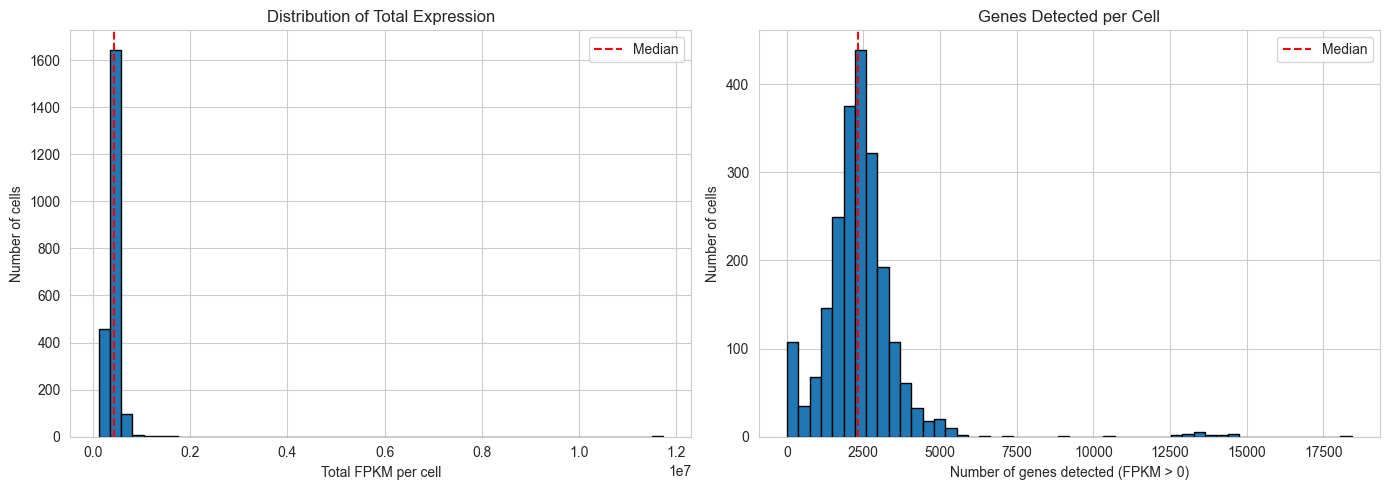

Median total FPKM per cell: 425334.91
Median genes detected per cell: 2328


In [43]:
# Calculate QC metrics
cell_meta_df['total_counts'] = expr_df.sum(axis=0).values
cell_meta_df['n_genes_detected'] = (expr_df > 0).sum(axis=0).values

# Plot QC metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total expression per cell
axes[0].hist(cell_meta_df['total_counts'], bins=50, edgecolor='black')
axes[0].set_xlabel('Total FPKM per cell')
axes[0].set_ylabel('Number of cells')
axes[0].set_title('Distribution of Total Expression')
axes[0].axvline(cell_meta_df['total_counts'].median(), color='red', linestyle='--', label='Median')
axes[0].legend()

# Number of genes detected per cell
axes[1].hist(cell_meta_df['n_genes_detected'], bins=50, edgecolor='black')
axes[1].set_xlabel('Number of genes detected (FPKM > 0)')
axes[1].set_ylabel('Number of cells')
axes[1].set_title('Genes Detected per Cell')
axes[1].axvline(cell_meta_df['n_genes_detected'].median(), color='red', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Median total FPKM per cell: {cell_meta_df['total_counts'].median():.2f}")
print(f"Median genes detected per cell: {cell_meta_df['n_genes_detected'].median():.0f}")

In [44]:
# Check how many cells per mouse and time point
print("Cells per mouse:")
print(cell_meta_df.groupby(['time_point', 'mouse']).size().unstack(fill_value=0))

print("\n\nTotal cells per mouse (across all time points):")
print(cell_meta_df['mouse'].value_counts().sort_index())

# Well-plate format detection — use the already-parsed 'well' column
# (some cell names have 5 parts, e.g. CKp25_6w_m4_H9_0, so split('_')[-1] is unreliable)
print("\n\nWell positions used (to see if it's 96-well or 384-well):")
wells = cell_meta_df['well'].values
well_letters = [w[0]  for w in wells if len(w) >= 2 and w[0].isalpha()]
well_numbers = [int(w[1:]) for w in wells if len(w) >= 2 and w[0].isalpha() and w[1:].isdigit()]

print(f"Row letters : {sorted(set(well_letters))}")
print(f"Column range: {min(well_numbers)} – {max(well_numbers)}")

if well_letters and well_numbers:
    if max(well_numbers) <= 12 and max(well_letters) <= 'H':
        print("\n→ 96-well plate format (8 rows × 12 columns)")
    elif max(well_numbers) <= 24 and max(well_letters) <= 'P':
        print("\n→ 384-well plate format (16 rows × 24 columns)")
    else:
        print(f"\n→ Custom plate format")


Cells per mouse:
mouse        m1   m2   m3  m4
time_point                   
0w          192  192  192   0
1w          192  192  192   0
2w          192  192  192   0
6w           94  105  185  96


Total cells per mouse (across all time points):
mouse
m1    670
m2    681
m3    761
m4     96
Name: count, dtype: int64


Well positions used (to see if it's 96-well or 384-well):
Row letters : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
Column range: 1 – 12

→ 96-well plate format (8 rows × 12 columns)


## Step 7: Identify Key Microglia Marker Genes

Let's find the most relevant genes for microglia biology and neurodegeneration.

In [45]:
# Define key microglia marker genes
microglia_markers = {
    'Homeostatic': ['Cx3cr1', 'Tmem119', 'P2ry12', 'Gpr34', 'Fcrls', 'Siglech'],
    'Pan-microglia': ['Aif1', 'Csf1r', 'Itgam', 'Hexb'],  # Aif1 = Iba1, Itgam = Cd11b
    'Activated/DAM': ['Apoe', 'Trem2', 'Tyrobp', 'Axl', 'Cd68', 'Lpl', 'Cst7'],  # DAM = Disease-Associated Microglia
    'Inflammatory': ['Il1b', 'Tnf', 'Il6', 'Nos2', 'Ccl2', 'Ccl3', 'Ccl4'],
    'Complement': ['C1qa', 'C1qb', 'C1qc'],
    'Phagocytosis': ['Cd68', 'Cd74', 'Clec7a', 'Mrc1'],
}

# Check which markers are present in the data
print("Marker genes present in dataset:\n")
all_genes = set(expr_df.index)
for category, genes in microglia_markers.items():
    present = [g for g in genes if g in all_genes]
    missing = [g for g in genes if g not in all_genes]
    print(f"{category}:")
    print(f"  ✓ Present ({len(present)}): {', '.join(present)}")
    if missing:
        print(f"  ✗ Missing ({len(missing)}): {', '.join(missing)}")
    print()

Marker genes present in dataset:

Homeostatic:
  ✓ Present (6): Cx3cr1, Tmem119, P2ry12, Gpr34, Fcrls, Siglech

Pan-microglia:
  ✓ Present (4): Aif1, Csf1r, Itgam, Hexb

Activated/DAM:
  ✓ Present (7): Apoe, Trem2, Tyrobp, Axl, Cd68, Lpl, Cst7

Inflammatory:
  ✓ Present (7): Il1b, Tnf, Il6, Nos2, Ccl2, Ccl3, Ccl4

Complement:
  ✓ Present (3): C1qa, C1qb, C1qc

Phagocytosis:
  ✓ Present (4): Cd68, Cd74, Clec7a, Mrc1



In [46]:
# Find most variable genes (likely most biologically relevant)
gene_var = expr_df.var(axis=1)
gene_mean = expr_df.mean(axis=1)

# Filter out very low expression genes
expressed_genes = gene_mean[gene_mean > 1].index
gene_var_filtered = gene_var[expressed_genes]

# Top 20 most variable genes
top_variable = gene_var_filtered.nlargest(20)

print("Top 20 most variable genes (excluding low expression):\n")
for i, (gene, variance) in enumerate(top_variable.items(), 1):
    mean_expr = gene_mean[gene]
    print(f"{i:2d}. {gene:15s} - var: {variance:8.2f}, mean: {mean_expr:6.2f}")

# Check if these overlap with our markers
marker_genes_flat = [g for genes in microglia_markers.values() for g in genes]
overlap = set(top_variable.index) & set(marker_genes_flat)
print(f"\n{len(overlap)} of top 20 variable genes are known microglia markers: {overlap}")

Top 20 most variable genes (excluding low expression):

 1. Mir7237         - var: 57027241492.39, mean: 5160.79
 2. Mir6236         - var: 1574159756.20, mean: 3335.68
 3. Cst3            - var: 463240735.20, mean: 25838.98
 4. Rn45s           - var: 324043629.71, mean: 30202.67
 5. Bhlhe41         - var: 219589893.57, mean: 16795.13
 6. Snord45b        - var: 219514030.94, mean: 409.98
 7. Snord34         - var: 105810124.98, mean: 1189.78
 8. Mir7238         - var: 93581304.79, mean: 205.87
 9. Mir6970         - var: 92017139.48, mean: 222.52
10. Mir686          - var: 90619007.06, mean: 2118.18
11. Mir142          - var: 82551146.13, mean: 388.63
12. Mir7672         - var: 77155675.15, mean: 592.15
13. Snord104        - var: 71437169.93, mean: 855.56
14. Apoe            - var: 65186670.22, mean: 2663.29
15. B2m             - var: 60480030.51, mean: 4448.59
16. Snord37         - var: 49656438.08, mean: 183.78
17. Snord42a        - var: 40198151.31, mean: 134.93
18. Mir5123         -

## Step 8: Differential Expression Analysis

Compare gene expression between time points to identify genes that change during neurodegeneration.

In [47]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Compare 0w (baseline) vs 6w (late disease) *within each condition*
early_tp   = ['0w']
late_tp    = ['6w']
conditions = sorted(cell_meta_df['condition'].unique())

def perform_de(condition):
    cond_cells  = cell_meta_df[cell_meta_df['condition'] == condition]
    early_cells = cond_cells[cond_cells['time_point'].isin(early_tp)]['cell_id'].values
    late_cells  = cond_cells[cond_cells['time_point'].isin(late_tp) ]['cell_id'].values
    print(f"{condition}: {len(early_cells)} early cells vs {len(late_cells)} late cells")
    results = []
    for gene in expr_df.index:
        ev = expr_df.loc[gene, early_cells].values
        lv = expr_df.loc[gene, late_cells].values
        em, lm = ev.mean(), lv.mean()
        log2fc = np.log2((lm + 1) / (em + 1))
        pval = stats.mannwhitneyu(ev, lv, alternative='two-sided')[1] \
               if em > 0.1 or lm > 0.1 else 1.0
        results.append(dict(gene=gene, early_mean=em, late_mean=lm,
                            log2fc=log2fc, pval=pval))
    df = pd.DataFrame(results)
    df['padj'] = multipletests(df['pval'], method='fdr_bh')[1]
    return df.sort_values('padj')

print(f"Running DE analysis for each condition ({early_tp[0]} vs {late_tp[0]}) ...\n")
de_by_cond = {c: perform_de(c) for c in conditions}
print("\nDone.")


Running DE analysis for each condition (0w vs 6w) ...

CK: 288 early cells vs 192 late cells
CKp25: 288 early cells vs 288 late cells

Done.


In [48]:
# Summary: significant genes per condition
for cond, df in de_by_cond.items():
    n05  = (df['padj'] < 0.05).sum()
    n01  = (df['padj'] < 0.01).sum()
    print(f"{cond}: {n05} significant genes (padj<0.05) | {n01} genes (padj<0.01)")


CK: 148 significant genes (padj<0.05) | 102 genes (padj<0.01)
CKp25: 1499 significant genes (padj<0.05) | 1097 genes (padj<0.01)


In [49]:
# Top up/downregulated genes and known marker status — per condition
marker_genes_flat = [g for genes in microglia_markers.values() for g in genes]

for cond in conditions:
    de = de_by_cond[cond]
    sig = de[de['padj'] < 0.05].copy()
    print(f"\n{'='*80}")
    print(f"CONDITION: {cond}   ({early_tp[0]} → {late_tp[0]})")
    print(f"{'='*80}")

    print(f"\nTop 10 UPREGULATED:")
    for row in sig[sig['log2fc'] > 0].nlargest(10, 'log2fc').itertuples():
        print(f"  {row.gene:15s}  FC={2**row.log2fc:6.2f}x  padj={row.padj:.2e}"
              f"  {row.early_mean:6.1f} → {row.late_mean:6.1f}")

    print(f"\nTop 10 DOWNREGULATED:")
    for row in sig[sig['log2fc'] < 0].nsmallest(10, 'log2fc').itertuples():
        print(f"  {row.gene:15s}  FC={2**row.log2fc:6.2f}x  padj={row.padj:.2e}"
              f"  {row.early_mean:6.1f} → {row.late_mean:6.1f}")

    de_markers = sig[sig['gene'].isin(marker_genes_flat)].sort_values('log2fc', ascending=False)
    print(f"\nKnown microglia markers ({len(de_markers)} DE):")
    for row in de_markers.itertuples():
        arrow = '\u2191' if row.log2fc > 0 else '\u2193'
        print(f"  {arrow} {row.gene:15s}  FC={2**row.log2fc:6.2f}x  padj={row.padj:.2e}")



CONDITION: CK   (0w → 6w)

Top 10 UPREGULATED:
  Ccl5             FC=  7.04x  padj=5.30e-05     1.7 →   18.0
  Spp1             FC=  3.61x  padj=2.51e-02     0.4 →    4.1
  Angptl7          FC=  2.93x  padj=2.56e-03    12.6 →   38.9
  Egr2             FC=  2.70x  padj=3.01e-02     7.0 →   20.6
  Ier3             FC=  2.54x  padj=2.27e-04    44.7 →  115.2
  Ccl4             FC=  2.52x  padj=8.89e-04   144.2 →  365.3
  Itgax            FC=  2.52x  padj=1.57e-02     0.7 →    3.4
  Ccdc80           FC=  2.31x  padj=4.05e-03     2.1 →    6.1
  Gm15880          FC=  2.28x  padj=7.17e-03     1.7 →    5.0
  Siglec5          FC=  2.18x  padj=2.95e-02     9.2 →   21.1

Top 10 DOWNREGULATED:
  Slc30a4          FC=  0.15x  padj=4.62e-04     7.0 →    0.2
  Upk1b            FC=  0.28x  padj=4.58e-02    50.3 →   13.2
  Chtf8            FC=  0.31x  padj=4.32e-02    19.6 →    5.4
  Npm3-ps1         FC=  0.32x  padj=3.36e-02    16.3 →    4.5
  Nrp1             FC=  0.32x  padj=2.24e-04    28.2 →    8.3

/tmp/ipykernel_58534/1864165328.py:37: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_58534/1864165328.py:37: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_58534/1864165328.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_58534/1864165328.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(out_dir / 'volcano_by_condition.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_58534/1864165328.py:38: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(out_dir / 'volcano_by_condition.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_58534/1864165328.py:38: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(out_dir / 'volcano_by_condition.png', dpi=150, bbox_inches='tight')
/home/tristan/Research/

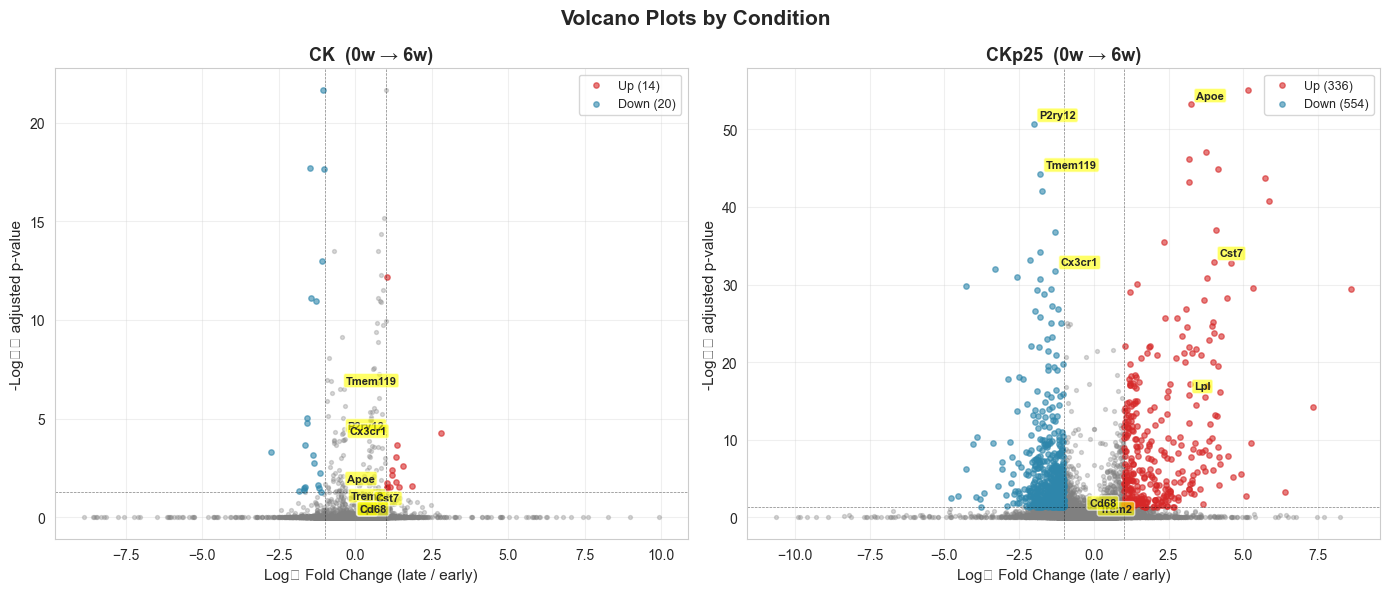

In [50]:
# Volcano plots — one per condition
key_genes_to_label = ['Apoe', 'Trem2', 'Cst7', 'Lpl', 'P2ry12', 'Tmem119', 'Cx3cr1', 'Cd68']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cond in zip(axes, conditions):
    de = de_by_cond[cond]
    sig_up   = de[(de['padj'] < 0.05) & (de['log2fc'] >  1)]
    sig_down = de[(de['padj'] < 0.05) & (de['log2fc'] < -1)]
    ns       = de[~de.index.isin(sig_up.index) & ~de.index.isin(sig_down.index)]

    ax.scatter(ns['log2fc'],       -np.log10(ns['padj']),       alpha=0.3, s=8,  c='gray')
    ax.scatter(sig_up['log2fc'],   -np.log10(sig_up['padj']),   alpha=0.6, s=15, c='#D62828',
               label=f'Up ({len(sig_up)})')
    ax.scatter(sig_down['log2fc'], -np.log10(sig_down['padj']), alpha=0.6, s=15, c='#2E86AB',
               label=f'Down ({len(sig_down)})')

    ax.axhline(-np.log10(0.05), color='k', lw=0.5, ls='--', alpha=0.5)
    ax.axvline( 1,  color='k', lw=0.5, ls='--', alpha=0.5)
    ax.axvline(-1,  color='k', lw=0.5, ls='--', alpha=0.5)

    # Label key genes
    for gene in key_genes_to_label:
        row = de[de['gene'] == gene]
        if not row.empty:
            ax.annotate(gene, xy=(row['log2fc'].values[0], -np.log10(row['padj'].values[0])),
                        xytext=(4, 4), textcoords='offset points', fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.6))

    ax.set_xlabel('Log₂ Fold Change (late / early)', fontsize=11)
    ax.set_ylabel('-Log₁₀ adjusted p-value', fontsize=11)
    ax.set_title(f'{cond}  ({early_tp[0]} → {late_tp[0]})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Volcano Plots by Condition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'volcano_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()


Showing 50 CKp25-specific genes in heatmap


/tmp/ipykernel_58534/343483120.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_58534/343483120.py:47: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(out_dir / 'heatmap_ckp25_specific.png', dpi=150, bbox_inches='tight')
/home/tristan/Research/Sp26/WPT/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


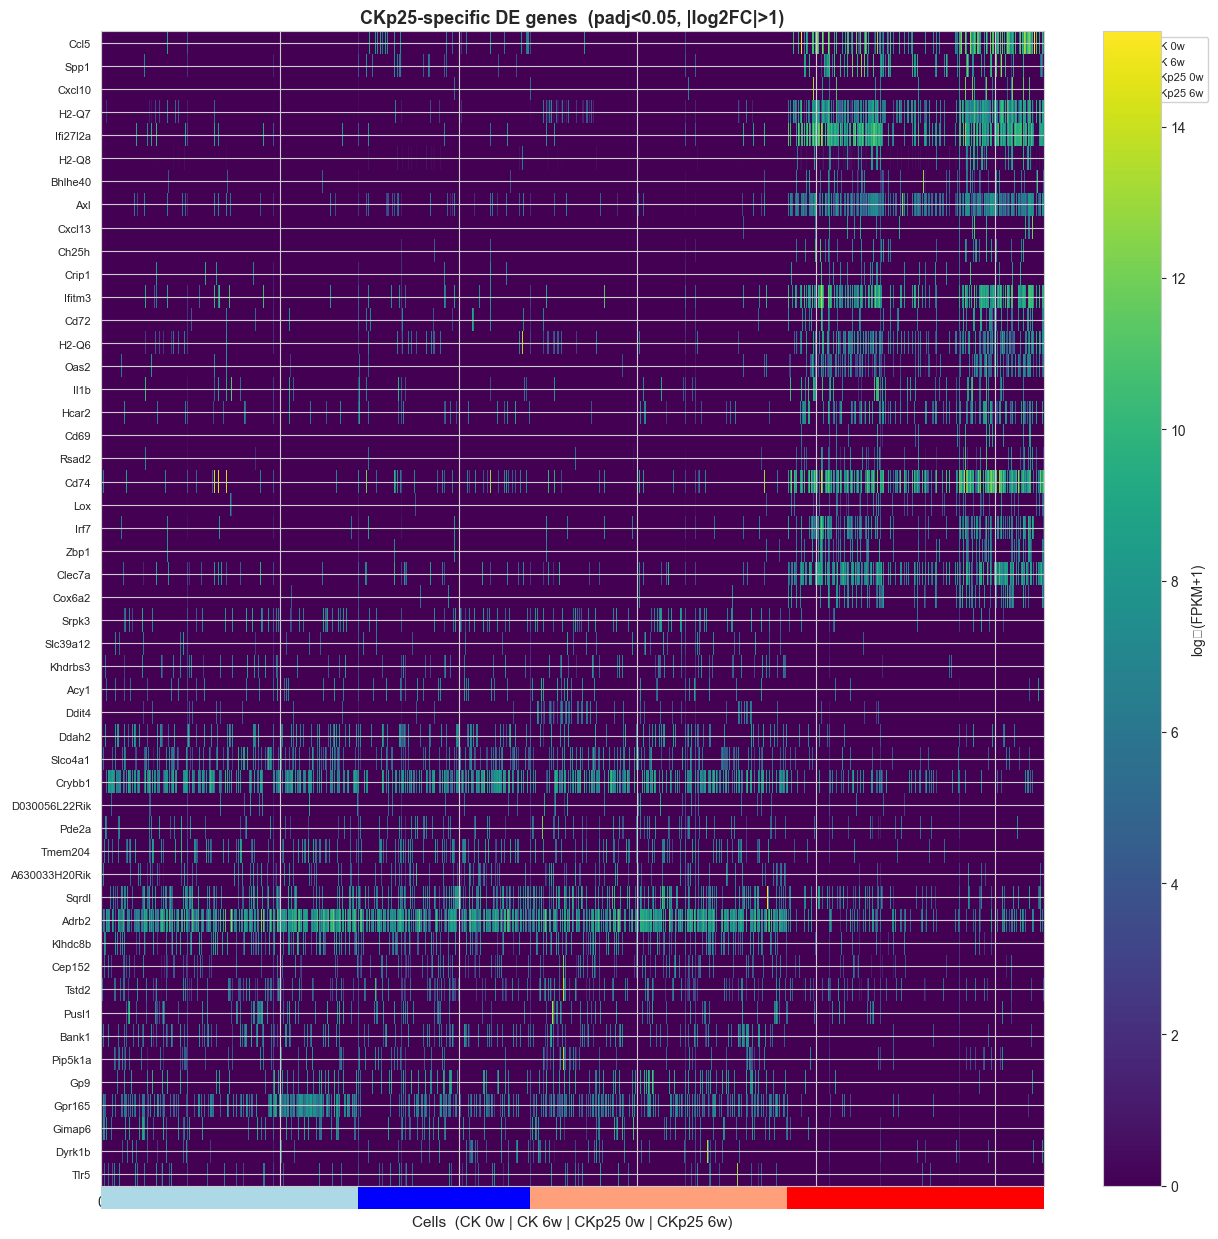

In [51]:
# Heatmap of CKp25-specific genes
# Rows  = genes significantly changed in CKp25 (padj<0.05, |log2fc|>1)
# Cols  = cells from both conditions at 0w and 6w (4 colour-coded groups)
ckp25_de = de_by_cond['CKp25']
ckp25_sig_genes = ckp25_de[
    (ckp25_de['padj'] < 0.05) & (ckp25_de['log2fc'].abs() > 1)
].sort_values('log2fc', ascending=False)
top_de_genes = pd.concat([
    ckp25_sig_genes[ckp25_sig_genes['log2fc'] > 0].head(25),
    ckp25_sig_genes[ckp25_sig_genes['log2fc'] < 0].tail(25),
])['gene'].values
print(f"Showing {len(top_de_genes)} CKp25-specific genes in heatmap")

# Collect cells for 4 groups: CK 0w, CK 6w, CKp25 0w, CKp25 6w
groups = [('CK','0w','lightblue'), ('CK','6w','blue'),
          ('CKp25','0w','lightsalmon'), ('CKp25','6w','red')]
all_cells, col_colors = [], []
for cond, tp, color in groups:
    mask  = (cell_meta_df['condition'] == cond) & (cell_meta_df['time_point'] == tp)
    cells = cell_meta_df[mask]['cell_id'].values
    all_cells.extend(cells)
    col_colors.extend([color] * len(cells))

heatmap_data = np.log2(expr_df.loc[top_de_genes, all_cells] + 1)

fig, ax = plt.subplots(figsize=(13, max(6, len(top_de_genes) * 0.25)))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='viridis', interpolation='nearest')
ax.set_yticks(range(len(top_de_genes)))
ax.set_yticklabels(top_de_genes, fontsize=8)
ax.set_xlabel('Cells  (CK 0w | CK 6w | CKp25 0w | CKp25 6w)', fontsize=11)
ax.set_title('CKp25-specific DE genes  (padj<0.05, |log2FC|>1)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='log₂(FPKM+1)')

# Colour bar across the top
for i, color in enumerate(col_colors):
    ax.add_patch(plt.Rectangle((i - 0.5, len(top_de_genes) - 0.5), 1, 1,
                                facecolor=color, edgecolor='none', clip_on=False,
                                transform=ax.transData))

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=f'{cond} {tp}')
                  for cond, tp, c in groups]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8,
          bbox_to_anchor=(1.18, 1), framealpha=0.9)

plt.tight_layout()
plt.savefig(out_dir / 'heatmap_ckp25_specific.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 9: Temporal Evolution of Key Genes

Visualize how important microglia genes change over time during neurodegeneration.

In [52]:
# Select key genes to track over time
key_genes = {
    'Homeostatic markers': ['P2ry12', 'Tmem119', 'Cx3cr1'],
    'DAM markers': ['Apoe', 'Trem2', 'Cd68'],
    'Inflammatory': ['Il1b', 'Tnf', 'Ccl2'],
    'Complement': ['C1qa', 'C1qb', 'C1qc']
}

# Calculate mean expression per time point for each gene
time_points = sorted(cell_meta_df['time_point'].unique())
print(f"Time points in dataset: {time_points}")

# Create data structure for plotting
gene_trajectories = {}

for category, genes in key_genes.items():
    for gene in genes:
        if gene in expr_df.index:
            means = []
            sems = []  # Standard error of the mean
            
            for tp in time_points:
                cells = cell_meta_df[cell_meta_df['time_point'] == tp]['cell_id'].values
                expr_values = expr_df.loc[gene, cells].values
                means.append(np.mean(expr_values))
                sems.append(np.std(expr_values) / np.sqrt(len(expr_values)))
            
            gene_trajectories[gene] = {
                'category': category,
                'means': means,
                'sems': sems
            }

print(f"\nTracking {len(gene_trajectories)} genes across {len(time_points)} time points")

Time points in dataset: ['0w', '1w', '2w', '6w']

Tracking 12 genes across 4 time points


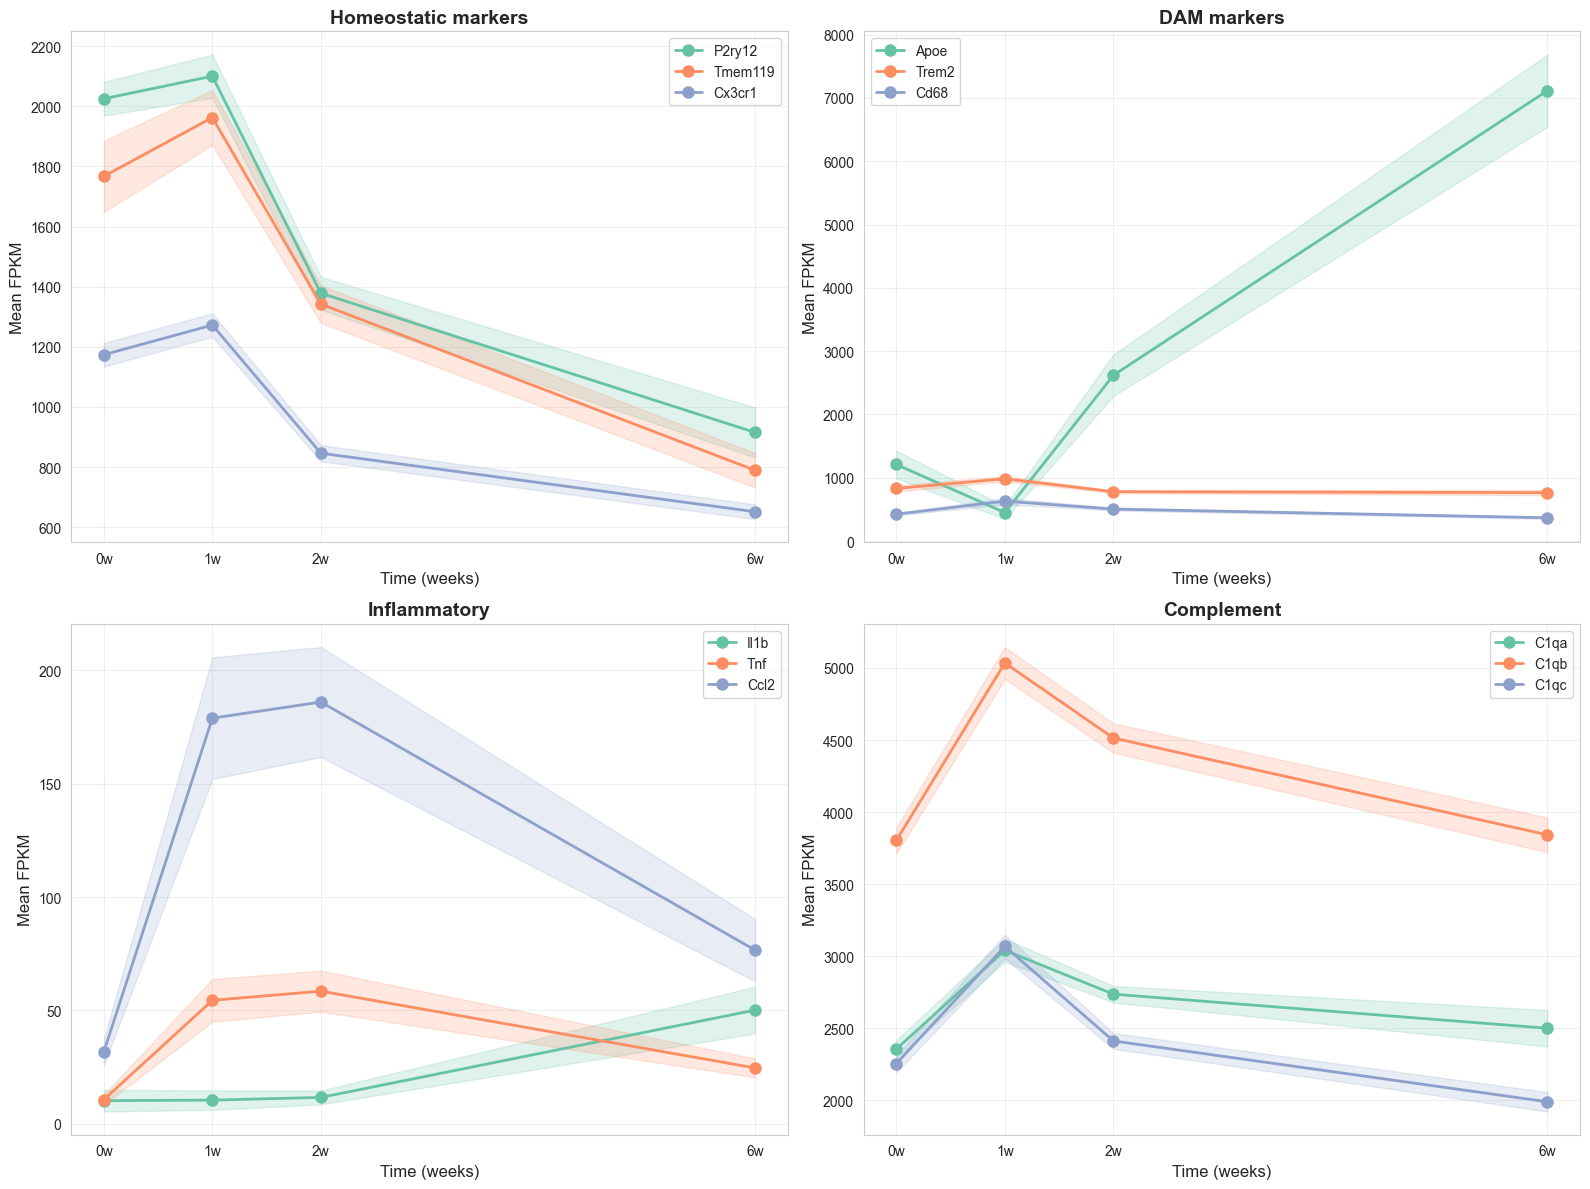

Saved: {out_dir / 'temporal_evolution.png'}


In [53]:
# Plot temporal evolution - one subplot per category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

categories = list(key_genes.keys())
colors = plt.cm.Set2(range(8))

for idx, category in enumerate(categories):
    ax = axes[idx]
    
    # Plot each gene in this category
    color_idx = 0
    for gene, data in gene_trajectories.items():
        if data['category'] == category:
            # Convert time points to numeric (extract number from '0w', '1w', etc.)
            time_numeric = [int(tp.replace('w', '')) if 'w' in tp else 0 for tp in time_points]
            
            # Plot line with error bars
            ax.plot(time_numeric, data['means'], marker='o', label=gene, 
                   linewidth=2, markersize=8, color=colors[color_idx])
            ax.fill_between(time_numeric, 
                           np.array(data['means']) - np.array(data['sems']),
                           np.array(data['means']) + np.array(data['sems']),
                           alpha=0.2, color=colors[color_idx])
            color_idx += 1
    
    ax.set_xlabel('Time (weeks)', fontsize=12)
    ax.set_ylabel('Mean FPKM', fontsize=12)
    ax.set_title(category, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(time_numeric)
    ax.set_xticklabels(time_points)

plt.tight_layout()
plt.savefig(out_dir / 'temporal_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: {out_dir / 'temporal_evolution.png'}")

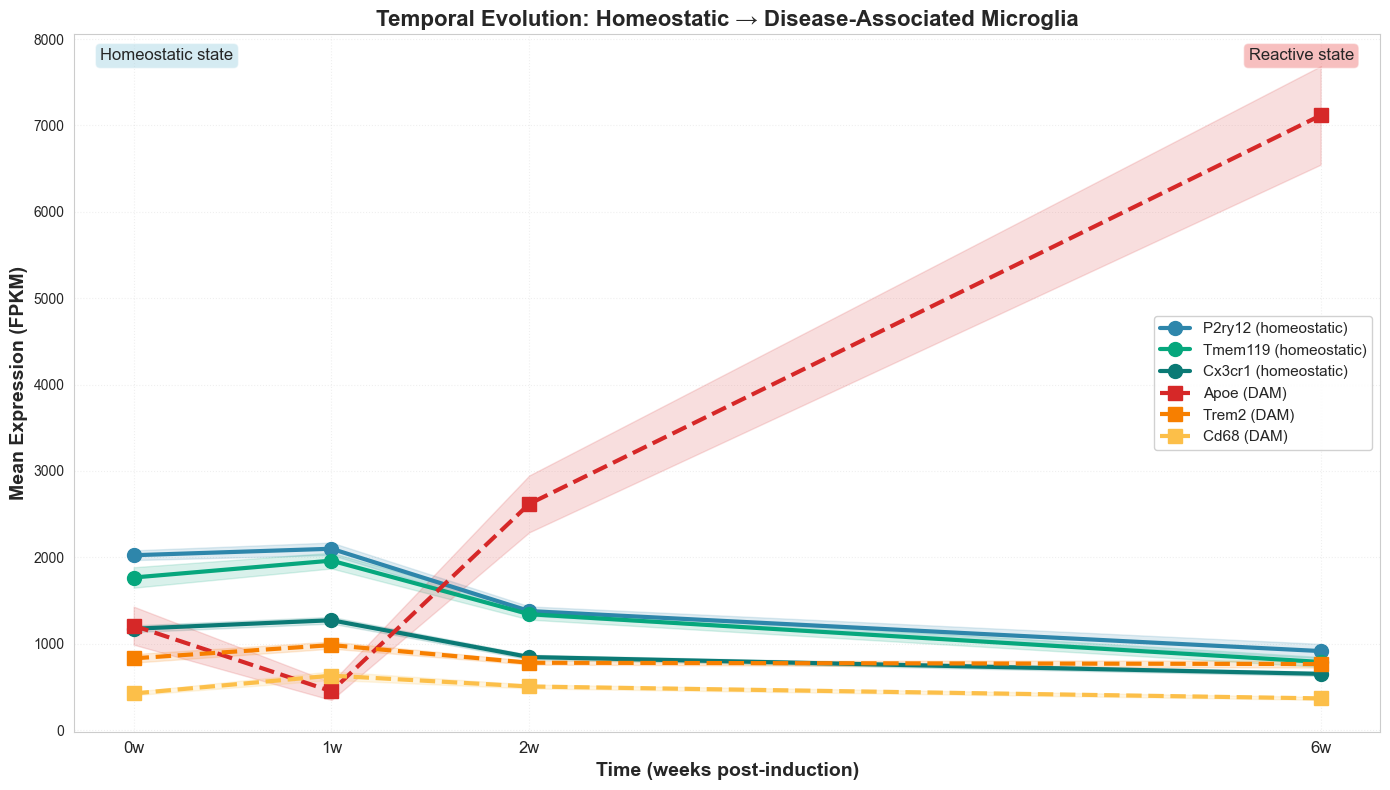

\nKey observations:
- Solid lines (○) = Homeostatic markers (should decrease)
- Dashed lines (□) = DAM markers (should increase)
\nSaved: {out_dir / 'homeostatic_vs_dam.png'}


In [54]:
# Combined plot - homeostatic vs DAM markers
fig, ax = plt.subplots(figsize=(14, 8))

# Plot homeostatic markers (should decrease)
homeostatic_genes = ['P2ry12', 'Tmem119', 'Cx3cr1']
homeostatic_colors = ['#2E86AB', '#06A77D', '#0B7A75']

# Plot DAM markers (should increase)
dam_genes = ['Apoe', 'Trem2', 'Cd68']
dam_colors = ['#D62828', '#F77F00', '#FCBF49']

time_numeric = [int(tp.replace('w', '')) if 'w' in tp else 0 for tp in time_points]

# Plot homeostatic markers
for gene, color in zip(homeostatic_genes, homeostatic_colors):
    if gene in gene_trajectories:
        data = gene_trajectories[gene]
        ax.plot(time_numeric, data['means'], marker='o', label=f'{gene} (homeostatic)', 
               linewidth=3, markersize=10, color=color, linestyle='-')
        ax.fill_between(time_numeric, 
                       np.array(data['means']) - np.array(data['sems']),
                       np.array(data['means']) + np.array(data['sems']),
                       alpha=0.15, color=color)

# Plot DAM markers  
for gene, color in zip(dam_genes, dam_colors):
    if gene in gene_trajectories:
        data = gene_trajectories[gene]
        ax.plot(time_numeric, data['means'], marker='s', label=f'{gene} (DAM)', 
               linewidth=3, markersize=10, color=color, linestyle='--')
        ax.fill_between(time_numeric, 
                       np.array(data['means']) - np.array(data['sems']),
                       np.array(data['means']) + np.array(data['sems']),
                       alpha=0.15, color=color)

ax.set_xlabel('Time (weeks post-induction)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Expression (FPKM)', fontsize=14, fontweight='bold')
ax.set_title('Temporal Evolution: Homeostatic → Disease-Associated Microglia', 
            fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xticks(time_numeric)
ax.set_xticklabels(time_points, fontsize=12)

# Add annotations
ax.text(0.02, 0.98, 'Homeostatic state', transform=ax.transAxes,
       fontsize=12, verticalalignment='top', 
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.text(0.98, 0.98, 'Reactive state', transform=ax.transAxes,
       fontsize=12, verticalalignment='top', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.savefig(out_dir / 'homeostatic_vs_dam.png', dpi=300, bbox_inches='tight')
plt.show()

print("\\nKey observations:")
print("- Solid lines (○) = Homeostatic markers (should decrease)")
print("- Dashed lines (□) = DAM markers (should increase)")
print("\\nSaved: {out_dir / 'homeostatic_vs_dam.png'}")

## Step 10: Temporal Analysis by Condition (CK vs CKp25)

Compare gene expression trajectories between control (CK) and disease model (CKp25) conditions.

In [55]:
# First, check what conditions we have
print("Conditions in dataset:")
condition_counts = cell_meta_df.groupby(['condition', 'time_point']).size().unstack(fill_value=0)
print(condition_counts)

print(f"\nUnique conditions: {sorted(cell_meta_df['condition'].unique())}")
print(f"\nCells per condition:")
print(cell_meta_df['condition'].value_counts())

Conditions in dataset:
time_point   0w   1w   2w   6w
condition                     
CK          288  288  288  192
CKp25       288  288  288  288

Unique conditions: ['CK', 'CKp25']

Cells per condition:
condition
CKp25    1152
CK       1056
Name: count, dtype: int64


In [56]:
# Calculate gene trajectories separately for each condition
conditions = sorted(cell_meta_df['condition'].unique())
time_points = sorted(cell_meta_df['time_point'].unique())

# Use same key genes as before
key_genes = {
    'Homeostatic markers': ['P2ry12', 'Tmem119', 'Cx3cr1'],
    'DAM markers': ['Apoe', 'Trem2', 'Cd68'],
    'Inflammatory': ['Il1b', 'Tnf', 'Ccl2'],
    'Complement': ['C1qa', 'C1qb', 'C1qc']
}

# Create nested structure: condition -> gene -> trajectory
gene_trajectories_by_condition = {}

for condition in conditions:
    gene_trajectories_by_condition[condition] = {}
    
    for category, genes in key_genes.items():
        for gene in genes:
            if gene in expr_df.index:
                means = []
                sems = []
                
                for tp in time_points:
                    # Filter by both condition AND time point
                    mask = (cell_meta_df['condition'] == condition) & (cell_meta_df['time_point'] == tp)
                    cells = cell_meta_df[mask]['cell_id'].values
                    
                    if len(cells) > 0:  # Only calculate if we have cells
                        expr_values = expr_df.loc[gene, cells].values
                        means.append(np.mean(expr_values))
                        sems.append(np.std(expr_values) / np.sqrt(len(expr_values)))
                    else:
                        means.append(np.nan)
                        sems.append(np.nan)
                
                gene_trajectories_by_condition[condition][gene] = {
                    'category': category,
                    'means': means,
                    'sems': sems
                }

print(f"Calculated trajectories for {len(conditions)} conditions across {len(time_points)} time points")
for condition in conditions:
    n_genes = len(gene_trajectories_by_condition[condition])
    print(f"  - {condition}: {n_genes} genes")

Calculated trajectories for 2 conditions across 4 time points
  - CK: 12 genes
  - CKp25: 12 genes


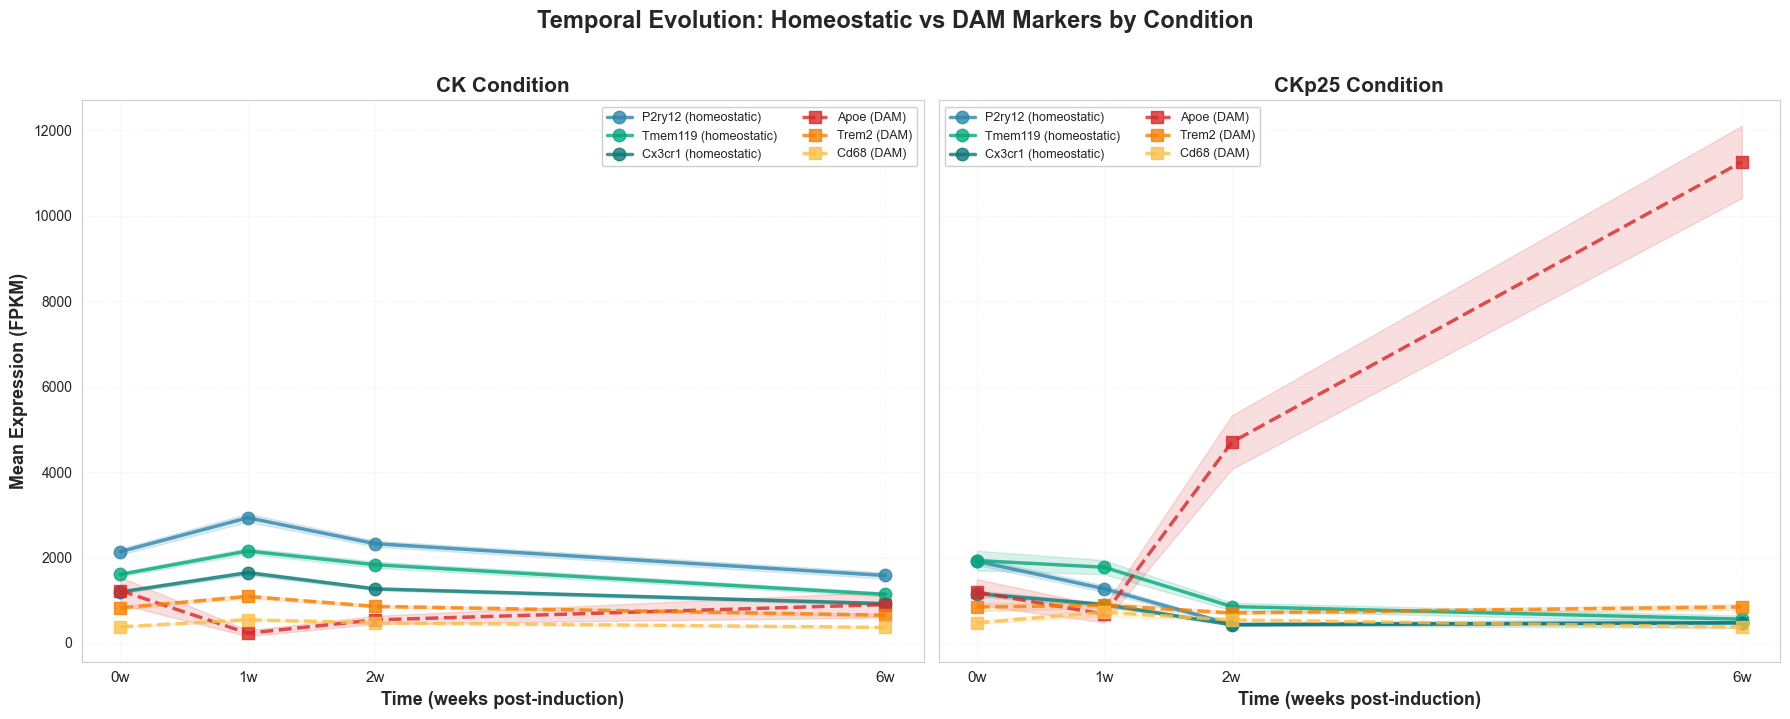


Key observations:
- Solid lines (○) = Homeostatic markers
- Dashed lines (□) = DAM markers
- Compare left (CK) vs right (CKp25) to see condition differences

Saved: {out_dir / 'temporal_by_condition.png'}


In [57]:
# Comparison plot: Homeostatic vs DAM markers for both conditions
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

homeostatic_genes = ['P2ry12', 'Tmem119', 'Cx3cr1']
homeostatic_colors = ['#2E86AB', '#06A77D', '#0B7A75']

dam_genes = ['Apoe', 'Trem2', 'Cd68']
dam_colors = ['#D62828', '#F77F00', '#FCBF49']

time_numeric = [int(tp.replace('w', '')) if 'w' in tp else 0 for tp in time_points]

for idx, condition in enumerate(conditions):
    ax = axes[idx]
    
    # Plot homeostatic markers
    for gene, color in zip(homeostatic_genes, homeostatic_colors):
        if gene in gene_trajectories_by_condition[condition]:
            data = gene_trajectories_by_condition[condition][gene]
            # Filter out NaN values
            valid_idx = [i for i, m in enumerate(data['means']) if not np.isnan(m)]
            valid_time = [time_numeric[i] for i in valid_idx]
            valid_means = [data['means'][i] for i in valid_idx]
            valid_sems = [data['sems'][i] for i in valid_idx]
            
            if len(valid_time) > 0:
                ax.plot(valid_time, valid_means, marker='o', label=f'{gene} (homeostatic)', 
                       linewidth=2.5, markersize=9, color=color, linestyle='-', alpha=0.8)
                ax.fill_between(valid_time, 
                               np.array(valid_means) - np.array(valid_sems),
                               np.array(valid_means) + np.array(valid_sems),
                               alpha=0.15, color=color)
    
    # Plot DAM markers  
    for gene, color in zip(dam_genes, dam_colors):
        if gene in gene_trajectories_by_condition[condition]:
            data = gene_trajectories_by_condition[condition][gene]
            # Filter out NaN values
            valid_idx = [i for i, m in enumerate(data['means']) if not np.isnan(m)]
            valid_time = [time_numeric[i] for i in valid_idx]
            valid_means = [data['means'][i] for i in valid_idx]
            valid_sems = [data['sems'][i] for i in valid_idx]
            
            if len(valid_time) > 0:
                ax.plot(valid_time, valid_means, marker='s', label=f'{gene} (DAM)', 
                       linewidth=2.5, markersize=9, color=color, linestyle='--', alpha=0.8)
                ax.fill_between(valid_time, 
                               np.array(valid_means) - np.array(valid_sems),
                               np.array(valid_means) + np.array(valid_sems),
                               alpha=0.15, color=color)
    
    ax.set_xlabel('Time (weeks post-induction)', fontsize=13, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Mean Expression (FPKM)', fontsize=13, fontweight='bold')
    ax.set_title(f'{condition} Condition', fontsize=15, fontweight='bold')
    ax.legend(fontsize=9, loc='best', framealpha=0.95, ncol=2)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_xticks(time_numeric)
    ax.set_xticklabels(time_points, fontsize=11)

plt.suptitle('Temporal Evolution: Homeostatic vs DAM Markers by Condition', 
            fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(out_dir / 'temporal_by_condition.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print("- Solid lines (○) = Homeostatic markers")
print("- Dashed lines (□) = DAM markers")
print("- Compare left (CK) vs right (CKp25) to see condition differences")
print("\nSaved: {out_dir / 'temporal_by_condition.png'}")

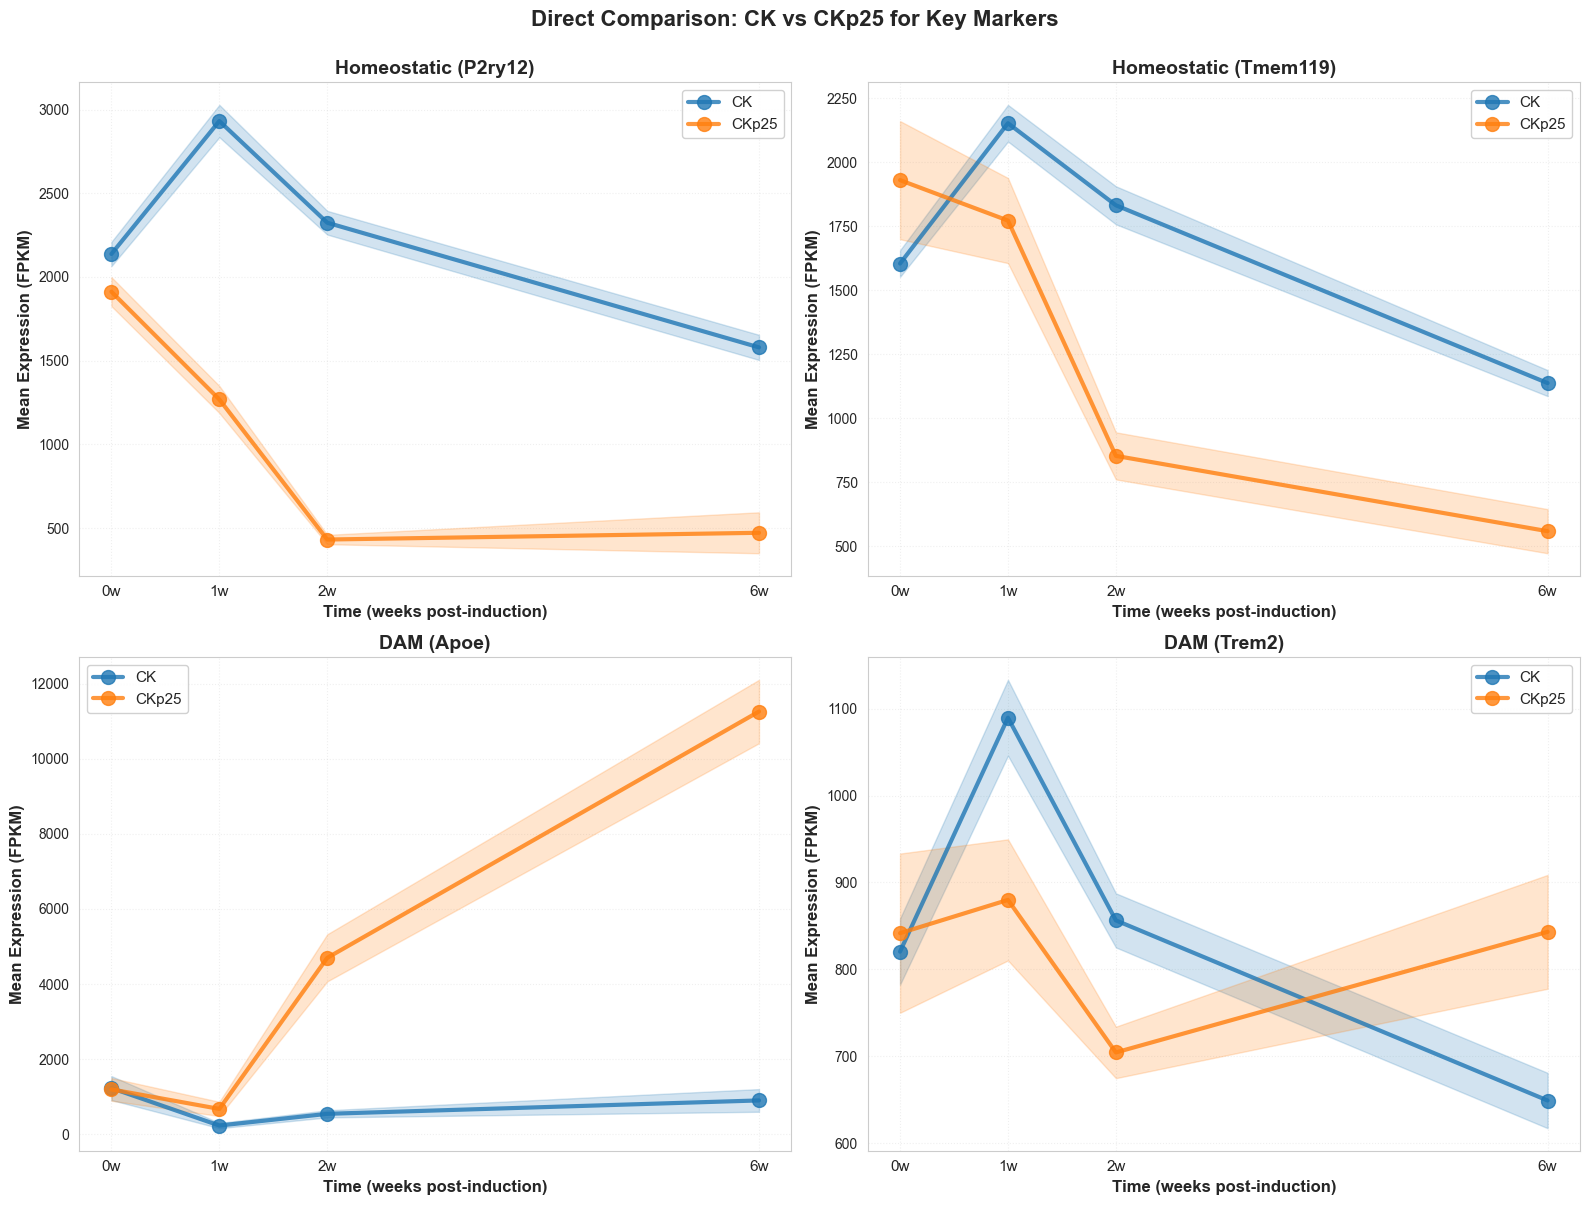


This plot shows direct overlay of both conditions for key genes
Expected pattern:
  - Homeostatic markers: should remain stable in CK, decrease in CKp25
  - DAM markers: should remain low in CK, increase in CKp25

Saved: {out_dir / 'condition_overlay_comparison.png'}


In [58]:
# Overlay plot: Direct comparison of conditions for key genes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Select representative genes from each category
representative_genes = {
    'Homeostatic (P2ry12)': 'P2ry12',
    'Homeostatic (Tmem119)': 'Tmem119', 
    'DAM (Apoe)': 'Apoe',
    'DAM (Trem2)': 'Trem2'
}

condition_colors = {
    conditions[0]: '#1f77b4',  # Blue for first condition (likely CK)
    conditions[1]: '#ff7f0e'   # Orange for second condition (likely CKp25)
}

time_numeric = [int(tp.replace('w', '')) if 'w' in tp else 0 for tp in time_points]

for idx, (title, gene) in enumerate(representative_genes.items()):
    ax = axes[idx]
    
    for condition in conditions:
        if gene in gene_trajectories_by_condition[condition]:
            data = gene_trajectories_by_condition[condition][gene]
            
            # Filter out NaN values
            valid_idx = [i for i, m in enumerate(data['means']) if not np.isnan(m)]
            valid_time = [time_numeric[i] for i in valid_idx]
            valid_means = [data['means'][i] for i in valid_idx]
            valid_sems = [data['sems'][i] for i in valid_idx]
            
            if len(valid_time) > 0:
                color = condition_colors[condition]
                ax.plot(valid_time, valid_means, marker='o', label=condition, 
                       linewidth=3, markersize=10, color=color, alpha=0.8)
                ax.fill_between(valid_time, 
                               np.array(valid_means) - np.array(valid_sems),
                               np.array(valid_means) + np.array(valid_sems),
                               alpha=0.2, color=color)
    
    ax.set_xlabel('Time (weeks post-induction)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Expression (FPKM)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_xticks(time_numeric)
    ax.set_xticklabels(time_points, fontsize=11)

plt.suptitle('Direct Comparison: CK vs CKp25 for Key Markers', 
            fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(out_dir / 'condition_overlay_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThis plot shows direct overlay of both conditions for key genes")
print("Expected pattern:")
print("  - Homeostatic markers: should remain stable in CK, decrease in CKp25")
print("  - DAM markers: should remain low in CK, increase in CKp25")
print("\nSaved: {out_dir / 'condition_overlay_comparison.png'}")